# Coffee Sales

## P3: Customer Segmentation & Anomaly Detection

- Objective: Group customers by behavior and detect unusual sales patterns.

    - Charts/Visuals:
        - Customer segmentation with K-Means (scatter plot on PCA components).
        - Cluster-wise average purchase value (bar chart).
        - Cluster sales trend (line chart).
        - Heatmap of cluster vs product preference.
        - Anomaly sales (Isolation Forest – scatter of normal vs anomaly).
    - ML Models:
        - K-Means Clustering – Segment customers by frequency, spend, and product mix.
        - Evaluation: Silhouette Score, Davies-Bouldin Index.
        - Isolation Forest / One-Class SVM – Detect anomalies in daily transactions (e.g., sudden spikes/drops).

In [2]:
# ============================
# P3: Customer Segmentation & Anomaly Detection
# ============================

# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import IsolationForest
import shap

# Set pastel theme
sns.set_theme(style="whitegrid", palette="pastel")

In [3]:
# ============================
# Load Dataset
# ============================
df = pd.read_csv("index.csv")

# Preview
print("Shape:", df.shape)
df.head()

Shape: (1133, 6)


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [4]:
# ============================
# Feature Engineering for Customers
# ============================
customer_df = df.groupby("card").agg({
    "money":"sum",         # total spend
    "coffee_name":"count"  # total purchases
}).rename(columns={"money":"total_spend","coffee_name":"num_purchases"})

# One-hot encode product preference
product_pref = pd.get_dummies(df[['card','coffee_name']], columns=["coffee_name"])
product_pref = product_pref.groupby("card").sum()

# Merge
customer_features = customer_df.join(product_pref)

# Scale
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_features)

In [5]:
# ============================
# K-Means Clustering
# ============================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_features)
customer_features["cluster"] = clusters

# Evaluation
silhouette = silhouette_score(scaled_features, clusters)
dbi = davies_bouldin_score(scaled_features, clusters)
print(f"K-Means → Silhouette Score: {silhouette:.2f}, DB Index: {dbi:.2f}")

K-Means → Silhouette Score: 0.91, DB Index: 0.05


In [6]:
# PCA for 2D visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
customer_features["pca1"] = pca_result[:,0]
customer_features["pca2"] = pca_result[:,1]

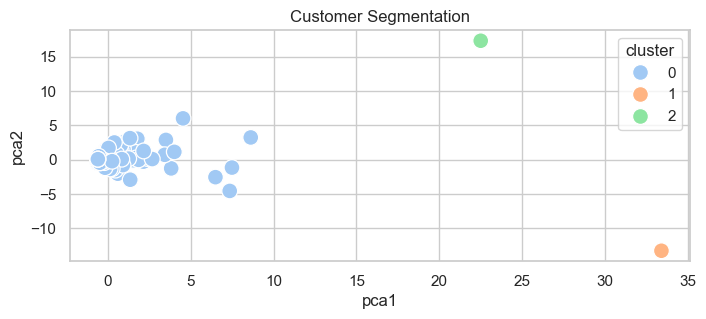

In [10]:
# ============================
# 1. Customer segmentation scatter plot (PCA)
# ============================
plt.figure(figsize=(8,3))
sns.scatterplot(data=customer_features, x="pca1", y="pca2", hue="cluster", palette="pastel", s=130)
plt.title("Customer Segmentation")
plt.show()

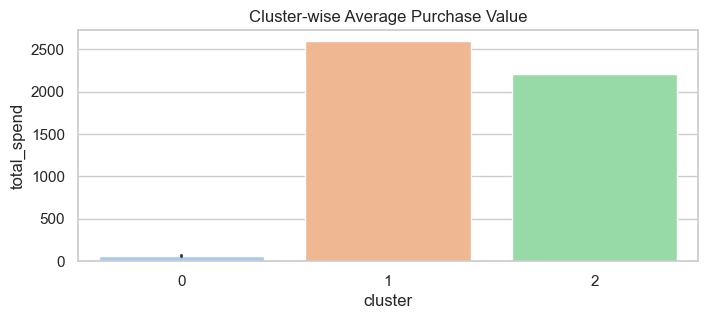

In [11]:
# ============================
# 2. Cluster-wise average spend
# ============================
import warnings
warnings.filterwarnings('ignore')
plt.figure(figsize=(8,3))
sns.barplot(data=customer_features, x="cluster", y="total_spend", estimator=np.mean, palette="pastel")
plt.title("Cluster-wise Average Purchase Value")
plt.show()

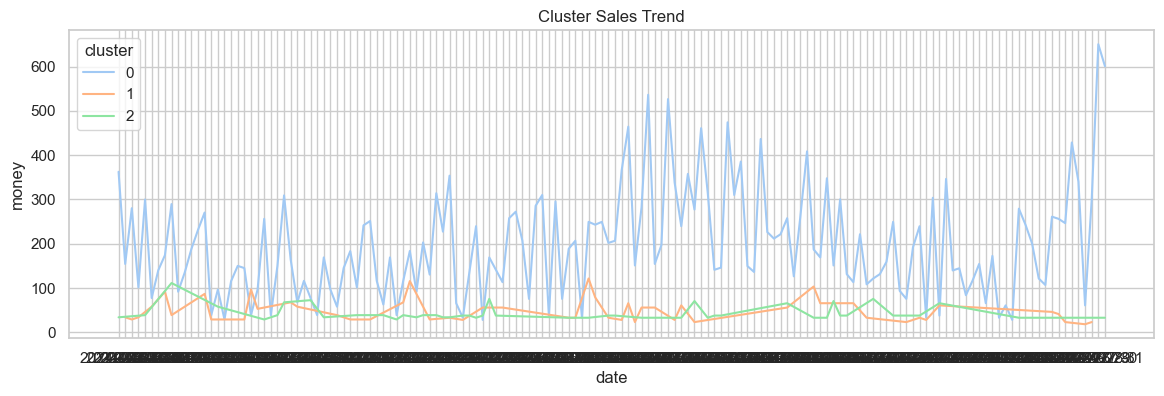

In [18]:
# ============================
# 3. Cluster sales trend
# ============================
cluster_sales = df.merge(customer_features["cluster"], left_on="card", right_index=True)
cluster_trend = cluster_sales.groupby(["date","cluster"])["money"].sum().reset_index()

plt.figure(figsize=(14,4))
sns.lineplot(data=cluster_trend, x="date", y="money", hue="cluster", palette="pastel")
plt.title("Cluster Sales Trend")
plt.show()

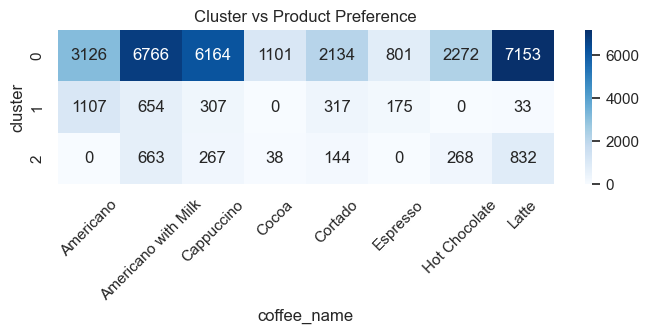

In [19]:
# ============================
# 4. Heatmap of cluster vs product preference
# ============================
cluster_pref = cluster_sales.groupby(["cluster","coffee_name"])["money"].sum().unstack().fillna(0)
plt.figure(figsize=(8,2))
sns.heatmap(cluster_pref, annot=True, fmt=".0f", cmap="Blues")
plt.title("Cluster vs Product Preference")
plt.xticks(rotation=45)
plt.show()

In [25]:
from sklearn.ensemble import IsolationForest

# Aggregate daily sales
daily = df.groupby("date")["money"].sum().reset_index()
iso = IsolationForest(contamination=0.05, random_state=42)
daily["anomaly"] = iso.fit_predict(daily[["money"]])

# anomaly = -1 means outlier, 1 means normal
print(daily['anomaly'].value_counts())

anomaly
 1    142
-1      8
Name: count, dtype: int64


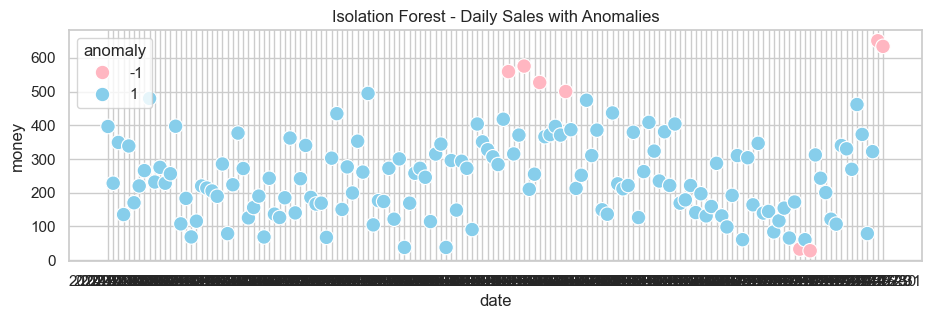

In [16]:
# ============================
# 5. Anomaly Detection (Isolation Forest)
# ============================
daily = df.groupby("date")["money"].sum().reset_index()
iso = IsolationForest(contamination=0.05, random_state=42)
daily["anomaly"] = iso.fit_predict(daily[["money"]])

plt.figure(figsize=(11,3))
sns.scatterplot(data=daily, x="date", y="money", hue="anomaly", palette={1:"#87CEEB",-1:"#FFB6C1"},s=110)
plt.title("Isolation Forest - Daily Sales with Anomalies")
plt.show()